In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import collections
import random

In [2]:
# --- 1. Wireless Environment Parameters ---
B_HZ = 1e6              # 1 MHz
N0_DBM_HZ = -174        # Noise density
P_TX_CLIENT_DBM = 24    # Uplink Power
P_TX_SERVER_DBM = 46    # Downlink Power (Server)
Q_BITS = 16             # 16-bit quantization
RADIUS_KM = 0.5         # 500m
DEVICE_GFLOPS = 2.0     # Average edge device speed (2 Billion operations/sec)

In [3]:
def plot_radar_map(r_km):
    """
    Plots 30 devices in a circular layout with index labels.
    Red triangle = Edge Server (Center)
    Blue dots = Edge Devices (Labeled 0-29)
    """
    # Generate random angles (theta) in radians
    theta = 2 * np.pi * np.random.rand(len(r_km)) 
    
    # Convert polar (r, theta) to Cartesian (x, y) for easier labeling
    x = r_km * np.cos(theta)
    y = r_km * np.sin(theta)
    
    plt.figure(figsize=(8, 8))
    
    # Plot the circular boundary (500m radius)
    circle = plt.Circle((0, 0), RADIUS_KM, color='gray', fill=False, linestyle='--', alpha=0.5)
    plt.gca().add_patch(circle)
    
    # Plot Edge Server at the center (0,0)
    plt.scatter(0, 0, c='red', marker='^', s=150, label='Edge Server', zorder=5)
    
    # Plot Edge Devices
    plt.scatter(x, y, c='skyblue', edgecolors='navy', s=80, alpha=0.8, label='Edge Devices')
    
    # Add Index Labels (0 to 29) for each device
    for i in range(len(r_km)):
        plt.annotate(f'{i}', (x[i], y[i]), xytext=(5, 5), 
                     textcoords='offset points', fontsize=9, fontweight='bold')

    plt.title(f"Device Distribution ({RADIUS_KM*1000}m Radius)")
    plt.xlabel("Distance (km)")
    plt.ylabel("Distance (km)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.2)
    plt.axis('equal') # Keep the circle from looking like an oval
    plt.xlim(-RADIUS_KM - 0.1, RADIUS_KM + 0.1)
    plt.ylim(-RADIUS_KM - 0.1, RADIUS_KM + 0.1)
    plt.show()

In [4]:
# --- 2. Model Architectures ---

class SVMModel(nn.Module):
    def __init__(self):
        super(SVMModel, self).__init__()
        self.fc = nn.Linear(3072, 1)
    def forward(self, x):
        return self.fc(x.view(x.size(0), -1))

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 5), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 5), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(nn.Linear(64 * 4 * 4, 512), nn.ReLU(), nn.Linear(512, 10))
    def forward(self, x):
        x = self.conv(x)
        return self.fc(x.view(x.size(0), -1))

In [5]:
# --- 3. Data Preparation ---

def get_datasets(task='CNN'):
    # Define a shared seed for reproducibility if needed, 
    # or remove it for different random splits each time.
    random.seed(42) 
    np.random.seed(42)

    if task == 'SVM':
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
        train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
        test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
        
        train_idx = [i for i, l in enumerate(train_set.targets) if l in [0, 1]]
        test_idx = [i for i, l in enumerate(test_set.targets) if l in [0, 1]]
        
        airplanes = [i for i in train_idx if train_set.targets[i] == 0][:15*330]
        autos = [i for i in train_idx if train_set.targets[i] == 1][:15*330]
        
        # Create the raw list of 30 Subsets
        all_subsets = [Subset(train_set, airplanes[i*330:(i+1)*330]) for i in range(15)] + \
                       [Subset(train_set, autos[i*330:(i+1)*330]) for i in range(15)]
        
        # RANDOMIZATION: Shuffle the list so 'Airplane devices' are spread 0-29
        random.shuffle(all_subsets)
        device_data = all_subsets
        
        return device_data, Subset(test_set, test_idx), SVMModel(), 0.0001

    else: # CNN Task (MNIST)
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
        train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
        
        # Pathological Non-IID: Sort by label to create shards
        indices = np.argsort(train_set.targets.numpy())
        shards = [indices[i*1000 : (i+1)*1000] for i in range(60)]
        
        # RANDOMIZATION: Shuffle the shards so Device 0 doesn't 
        # automatically get the 'lowest' labels (0 and 1)
        random.shuffle(shards)
        
        # Each device gets 2 random shards (each shard is likely 1 digit)
        device_data = [Subset(train_set, np.concatenate((shards[i*2], shards[i*2+1]))) for i in range(30)]
        
        return device_data, test_set, CNNModel(), 0.005
    
def observe_distribution(device_data, task='CNN'):
    # Determine how many classes to show
    num_labels = 10 if task == 'CNN' else 2
    distribution_matrix = np.zeros((30, num_labels))

    for i in range(30):
        subset = device_data[i]
        # Robustly handle different dataset target formats
        targets = subset.dataset.targets
        subset_labels = [int(targets[idx]) for idx in subset.indices]
        
        counts = collections.Counter(subset_labels)
        for label, count in counts.items():
            # For SVM, only record if label is 0 or 1
            if label < num_labels:
                distribution_matrix[i, label] = count

    # Plotting
    plt.figure(figsize=(8, 8)) # Narrower figure for 2 columns
    im = plt.imshow(distribution_matrix, cmap='YlGnBu', aspect='auto')
    
    plt.colorbar(im, label='Number of Samples')
    plt.title(f'Non-IID Heatmap: {task} Task', fontsize=14)
    plt.xlabel('Class Label', fontsize=12)
    plt.ylabel('Device Index', fontsize=12)
    
    # Set x-ticks specifically to the number of labels
    plt.xticks(range(num_labels))
    # If SVM, label them appropriately
    if task == 'SVM':
        plt.gca().set_xticklabels(['0 (Airplane)', '1 (Auto)'])
    
    plt.yticks(range(0, 30, 2))
    plt.tight_layout()
    plt.show()

In [6]:
def get_optimal_probabilities(n_k_list, grad_norms, T_u_list, rho):
    """
    Implements Theorem 1 - Importance- and channel-aware scheduling policy.
    """
    n_total = sum(n_k_list)
    grad_norms = np.array(grad_norms) + 1e-12 
    T_u_list = np.array(T_u_list)
    num_devices = len(n_k_list)

    floor_value = 0.0001 # Each device gets at least 1% chance
    total_floor = num_devices * floor_value
    remaining_budget = 1.0 - total_floor

    def apply_gaussian_top3(values, reverse=False):
        # 1. Start everyone with the 1% floor
        p = np.full(num_devices, floor_value)
        
        # 2. Identify the Top 3
        sorted_indices = np.argsort(values)
        if not reverse:
            sorted_indices = sorted_indices[::-1]
            
        # 3. Distribute the remaining 40% budget using Gaussian weights
        # Weights: Rank1 (1.0), Rank2 (0.606), Rank3 (0.135) -> Sum = 1.741
        raw_weights = np.array([1.0, 0.606, 0.135])
        normalized_weights = raw_weights / np.sum(raw_weights) # Scale to sum to 1.0
        
        # Add the budgeted share to the floor
        p[sorted_indices[0]] += normalized_weights[0] * remaining_budget
        p[sorted_indices[1]] += normalized_weights[1] * remaining_budget
        p[sorted_indices[2]] += normalized_weights[2] * remaining_budget
        
        return p

    # 1. New Behavior for rho = 0 (Channel-aware: Top 3 Fastest)
    if rho == 0:
        return apply_gaussian_top3(T_u_list, reverse=True)

    # 2. New Behavior for rho = 1 (Importance-aware: Top 3 Most Informative)
    if rho == 1:
        # Importance includes data weight n_k/n
        importance = (np.array(n_k_list) / n_total) * grad_norms
        return apply_gaussian_top3(importance, reverse=False)

    # 3. Proposed Policy (Intermediate rho)
    def compute_p_star(lam):
        denom = (1 - rho) * T_u_list + lam
        p = (np.array(n_k_list) / n_total) * grad_norms * np.sqrt(rho / np.maximum(denom, 1e-15))
        return p

    low = -np.min((1 - rho) * T_u_list) + 1e-12
    high = 1e6 
    
    for _ in range(100):
        mid = (low + high) / 2
        if np.sum(compute_p_star(mid)) > 1: low = mid
        else: high = mid

    lambda_star  = high
    final_p_raw = compute_p_star(lambda_star)
    return final_p_raw / np.sum(final_p_raw)

In [7]:
def get_multi_device_selection(n_k_list, grad_norms, T_u_list_full_B, rho, M):
    """
    Implements Algorithm 1: Importance- and Channel-Aware Scheduling 
    without replacement for M devices.
    """

    num_devices = len(n_k_list)

    # --- Pure Channel-Aware (Fastest M) ---
    if rho == 0:
        # Get indices of the M smallest latency values
        selected_indices = np.argsort(T_u_list_full_B)[:M].tolist()
        # Create a uniform p_star just for logging purposes
        p_star = np.zeros(num_devices)
        p_star[selected_indices] = 1.0 / M
        return selected_indices, p_star
    
    # --- Pure Importance-Aware ---
    if rho == 1:
        # Importance calculation consistent with Equation 14
        importance = (np.array(n_k_list) / sum(n_k_list)) * np.array(grad_norms)
        # Get indices of the M largest importance values
        selected_indices = np.argsort(importance)[-M:][::-1].tolist()
        # Create a uniform p_star for logging
        p_star = np.zeros(num_devices)
        p_star[selected_indices] = 1.0 / M
        return selected_indices, p_star
    
    # 1. Compute optimal scheduling distribution P* (Equation 25)
    p_star = get_optimal_probabilities(n_k_list, grad_norms, T_u_list_full_B, rho)
    
    selected_indices = []
    current_p = p_star.copy()
    
    for m in range(M):
        # Normalize current distribution to ensure sum = 1
        current_p = current_p / np.sum(current_p)
        
        # 2. Randomly select device based on conditional distribution
        idx = np.random.choice(range(len(p_star)), p=current_p)
        selected_indices.append(idx)
        
        # 3. The probability for this selected device becomes 0 in the next step
        current_p[idx] = 0
        
    return selected_indices, p_star

In [8]:
# --- 5. Main Training Logic ---

def run_multi_device_fl(task='SVM', training_time=10, rho=5e-6, M=10, r_km= RADIUS_KM * np.sqrt(np.random.rand(30))):
    device_data, test_set, global_model, lr = get_datasets(task)
    test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)
    n_k_list = [len(d) for d in device_data]
    n_total = sum(n_k_list)
    lmbda = 0.01 
    # Force 5 devices to be at the cell edge (450m - 500m) 
    # and 25 devices to be distributed normally.
    r_km = RADIUS_KM * np.sqrt(np.random.rand(30))
    r_km[:5] = 0.45 + (np.random.rand(5) * 0.05)
    
    history = {'acc': [], 'time': []}
    cumulative_time = 0

    print(f"\n--- Multi-Device Simulation: {task} | M={M} | Training Time: {training_time}s ---")

    while cumulative_time < training_time:
        # Communication Model 
        path_loss_db = 128.1 + 37.6 * np.log10(np.maximum(r_km, 0.01))
        
        noise_up_w = 10**(((N0_DBM_HZ + 10 * np.log10(B_HZ)) - 30) / 10)
        p_rx_up_w = 10**(((P_TX_CLIENT_DBM - path_loss_db) - 30) / 10)
        gamma_up = p_rx_up_w / noise_up_w
        
        p_rx_down_w = 10**(((P_TX_SERVER_DBM - path_loss_db) - 30) / 10)
        gamma_down_min = np.min(p_rx_down_w / noise_up_w) 
        
        num_params = sum(p.numel() for p in global_model.parameters())
        payload_bits = num_params * Q_BITS
        T_u_full_B = payload_bits / (B_HZ * np.log2(1 + gamma_up))

        # Importance Evaluation
        grad_norms = []
        client_gradients = []
        for i in range(30):
            # Step 1: Global Model Broadcast
            local_model = type(global_model)()
            local_model.load_state_dict(global_model.state_dict())
            loader = DataLoader(device_data[i], batch_size=len(device_data[i]))
            data, target = next(iter(loader))
            local_model.zero_grad()

            # Step 2: Local Gradient Calculation
            output = local_model(data).squeeze()
            if task == 'SVM':
                target_svm = (target.float() * 2) - 1 
                loss = 0.5 * torch.mean(torch.clamp(1 - target_svm * output, min=0)) + (lmbda / 2.0) * sum(p.pow(2).sum() for p in local_model.parameters())
            else:
                target_oh = torch.nn.functional.one_hot(target, num_classes=10).float()
                loss = 0.5 * torch.nn.functional.mse_loss(output, target_oh, reduction='mean')
            
            # Step 3: Importance Indicator Report
            loss.backward()
            grads = [p.grad.detach().clone() for p in local_model.parameters()]
            grad_norms.append(torch.norm(torch.cat([g.view(-1) for g in grads])).item())
            client_gradients.append(grads)

        # Step 4: Device Selection and Resource Allocation
        selected_indices, p_star = get_multi_device_selection(n_k_list, grad_norms, T_u_full_B, rho, M)
        print(f"Probability Policy: [Max: {100 * np.max(p_star):.2f}% - (Device {np.argmax(p_star)}) | "
        f"Min: {100 * np.min(p_star):.2f}% | Std: {100 * np.std(p_star):.2f}% | Sum: {100 * np.sum(p_star):.2f}% ]"
        f"\nSelected Devices: {selected_indices}" )

        # Step 5: Local Gradient Upload (Simulate Latency with Bandwidth Allocation - Theorem 3)
        # 1. Calculate the rate per unit bandwidth for selected devices
        R_k = np.log2(1 + gamma_up[selected_indices])
        
        # 2. Apply Theorem 3: Optimal Parallel Upload Time
        # This allows multiple devices to share the 'B' bandwidth efficiently
        sum_sqrt_inv_R = np.sum(np.sqrt(1.0 / R_k))
        t_upload_parallel = (payload_bits / B_HZ) * (sum_sqrt_inv_R**2)
        
        # 3. Standard overheads
        t_broadcast = payload_bits / (B_HZ * np.log2(1 + gamma_down_min))
        t_comp_max = (max(n_k_list) * 6000) / (DEVICE_GFLOPS * 1e9)
        
        # Total time for this specific round
        round_time = t_broadcast + t_comp_max + t_upload_parallel
        cumulative_time += round_time

        # Step 6: Global Model Update (Equation 29)
        with torch.no_grad():
            global_grad_sum = [torch.zeros_like(p) for p in global_model.parameters()]
            
            for m, idx in enumerate(selected_indices):
                if rho == 0 or rho == 1:
                    # --- FedAvg Style (Simple Average) ---
                    # We ignore the selection probability scaling entirely.
                    # Each of the M selected devices contributes 1/M to the update.
                    for g_sum, g_local in zip(global_grad_sum, client_gradients[idx]):
                        g_sum += (1.0 / M) * g_local
                else:
                    # --- Proposed Policy Style (Unbiased Estimator) ---
                    # Calculate conditional probability q_Y_m for Theorem 1 correctness
                    sum_prev_p = sum(p_star[selected_indices[j]] for j in range(m))
                    q_Y_m = p_star[idx] / np.maximum(1.0 - sum_prev_p, 1e-10)
                    
                    # Apply importance scale based on Equation 29
                    scale = n_k_list[idx] / (n_total * q_Y_m)
                    
                    for g_sum, g_local in zip(global_grad_sum, client_gradients[idx]):
                        # Clip only the proposed update to handle potential variance
                        update_val = (1.0 / M) * scale * g_local
                        g_sum += torch.clamp(update_val, min=-10.0, max=10.0)
            
            # Update global weights
            for p_global, g_agg in zip(global_model.parameters(), global_grad_sum):
                p_global -= lr * g_agg

        # Evaluation
        global_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for data, target in test_loader:
                output = global_model(data)
                pred = torch.sign(output.squeeze()) if task == 'SVM' else output.argmax(1)
                labels = (target.float()*2-1) if task == 'SVM' else target
                correct += (pred == labels).sum().item()
                total += target.size(0)
        
        acc = 100. * correct / total
        history['acc'].append(acc)
        history['time'].append(cumulative_time)
        
        print(f"Time: {cumulative_time:.3f}s / {training_time}s | Acc: {acc:.2f}%")

    return history

In [9]:
def run_multi_comparison(task='SVM', training_time=10):
    """
    Executes all multi-device scheduling policies for a specific task and plots the results.
    """
    # Define task-specific parameters based on Section VI.C 
    if task == 'SVM':
        M_devices = 10
        rhos = {0: 'Channel-aware', 
                1: 'Importance-aware',
                5e-4: 'Proposed (5e-4)',
                5e-6: 'Proposed (5e-6)'}
        time_scale = 1 # Seconds
        x_label = "Training Time (seconds)"
    else: # CNN
        M_devices = 3
        rhos = {0: 'Channel-aware', 
                1: 'Importance-aware', 
                1e-2: 'Proposed (1e-2)',
                1e-3: 'Proposed (1e-3)'}
        time_scale = 60 # Minutes
        x_label = "Training Time (minutes)"
    
    results = {}
    # Force 5 devices to be at the cell edge (450m - 500m) 
    # and 25 devices to be distributed normally.
    r_km = RADIUS_KM * np.sqrt(np.random.rand(30))
    r_km[:5] = 0.45 + (np.random.rand(5) * 0.05)
    plot_radar_map(r_km)

    print(f"--- Starting {task} Multi-Device Comparison (M={M_devices}) ---")
    for rho, label in rhos.items():
        print(f"Running {label} (rho={rho})...")
        # Ensure fresh model for each policy run
        results[label] = run_multi_device_fl(task=task, training_time=training_time, rho=rho, M=M_devices, r_km=r_km)

    # --- Plotting Results (Replicating Figure 4) ---
    plt.figure(figsize=(10, 6))
    for label, hist in results.items():
        # Convert time to appropriate scale (seconds or minutes)
        plt.plot(np.array(hist['time']) / time_scale, hist['acc'], label=label)
    
    plt.title(f"Multi-Device Performance Comparison: {task} Model (M={M_devices})")
    plt.xlabel(x_label)
    plt.ylabel("Test Accuracy (%)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# To execute the multi-device simulation:
# run_multi_comparison(task='SVM', training_time=10)
# run_multi_comparison(task='CNN', training_time=50)

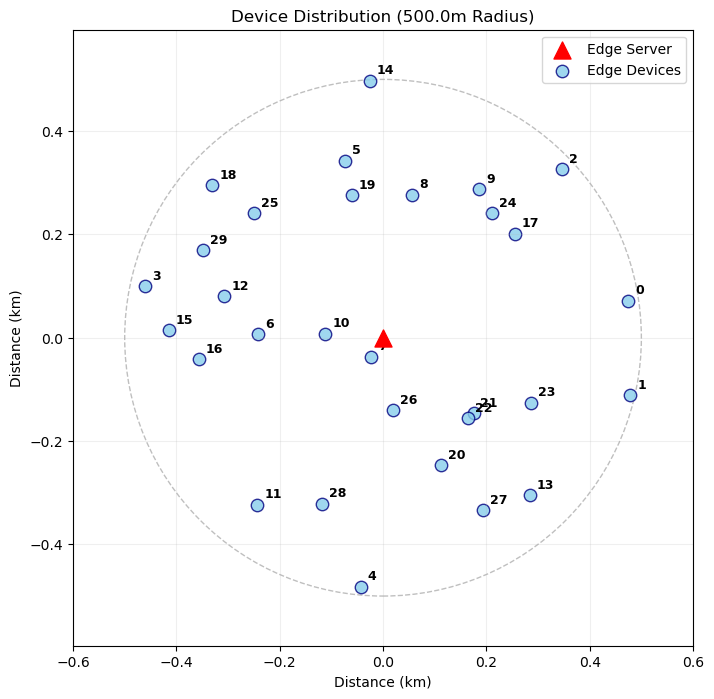

In [10]:
# Force 5 devices to be at the cell edge (450m - 500m) 
# and 25 devices to be distributed normally.
r_km = RADIUS_KM * np.sqrt(np.random.rand(30))
r_km[:5] = 0.45 + (np.random.rand(5) * 0.05)
plot_radar_map(r_km)

In [14]:
def plot_fl_history(history, task_name="CNN", rho=0.01, M=3):
    # Extract data
    times = np.array(history['time'])
    accs = np.array(history['acc'])
    
    # Optional: Convert time to minutes if it's very long
    time_label = "Time (Seconds)"
    if times[-1] > 600:
        times = times / 60
        time_label = "Time (Minutes)"

    plt.figure(figsize=(10, 6))
    
    # Plot the raw accuracy (thin, light color)
    plt.plot(times, accs, alpha=0.3, color='steelblue', label='Raw Accuracy')
    
    # Plot a moving average (thick, bold color) to see the trend
    window_size = 10
    if len(accs) > window_size:
        smoothed_accs = np.convolve(accs, np.ones(window_size)/window_size, mode='valid')
        plt.plot(times[window_size-1:], smoothed_accs, color='navy', linewidth=2, label=f'Trend ({window_size}-round MA)')

    # Labels and Styling
    plt.title(f"Federated Learning Performance: {task_name}\n($\\rho={rho}$, $M={M}$ devices)", fontsize=14)
    plt.xlabel(time_label, fontsize=12)
    plt.ylabel("Test Accuracy (%)", fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    
    # Highlight the final accuracy
    plt.axhline(y=accs[-1], color='red', linestyle=':', alpha=0.6)
    plt.text(times[0], accs[-1], f'Final: {accs[-1]:.2f}%', color='red', fontweight='bold', va='bottom')

    plt.tight_layout()
    plt.show()

In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np

def extract_fl_logs_final(file_path, keyword, max_time=12000):
    """
    Ultra-robust extractor:
    1. Identifies the section by looking for the keyword (e.g., 'Channel').
    2. Extracts the first two numbers on any line containing 'Time' and 'Acc'.
    """
    data = {'acc': [], 'time': []}
    is_target_section = False
    
    try:
        with open(file_path, 'r') as f:
            for line in f:
                line_clean = line.strip()
                if not line_clean: continue
                
                # Update section toggle
                if ">>>" in line_clean or "Running" in line_clean:
                    if keyword.lower() in line_clean.lower():
                        is_target_section = True
                    else:
                        is_target_section = False
                
                # Extract data
                if is_target_section and "Time" in line_clean and "Acc" in line_clean:
                    # Find all numbers (integers or decimals) in the line
                    nums = re.findall(r"[-+]?\d*\.\d+|\d+", line_clean)
                    if len(nums) >= 2:
                        t = float(nums[0])
                        a = float(nums[1])
                        if t <= max_time:
                            data['time'].append(t)
                            data['acc'].append(a)
        return data
    except FileNotFoundError:
        print(f"Error: '{file_path}' not found.")
        return data

# --- 1. DATA EXTRACTION ---
log_file = 'output.log'
his1 = extract_fl_logs_final(log_file, "Channel", max_time=12000)
his2 = extract_fl_logs_final(log_file, "Importance", max_time=12000)
# Assuming 'his' (Proposed) is already defined or extracted similarly:
# his = extract_fl_logs_final(log_file, "Proposed", max_time=12000)

print(f"✅ Extraction Results:")
print(f"his1 (Channel): {len(his1['acc'])} rounds")
print(f"his2 (Importance): {len(his2['acc'])} rounds")

# --- 2. PLOTTING ---
if len(his1['acc']) > 0 or len(his2['acc']) > 0:
    plt.figure(figsize=(11, 6))

    def add_to_plot(history, label, color):
        if not history['acc']: return
        
        times = np.array(history['time']) / 60 # Minutes
        accs = np.array(history['acc'])
        
        # Raw data (faded)
        plt.plot(times, accs, alpha=0.15, color=color)
        
        # Trend line (Moving Average)
        window = 15
        if len(accs) > window:
            smoothed = np.convolve(accs, np.ones(window)/window, mode='valid')
            plt.plot(times[window-1:], smoothed, label=label, color=color, linewidth=2.5)
        else:
            plt.plot(times, accs, label=label, color=color, linewidth=2.5)

    add_to_plot(his1, "Channel-aware ($\\rho=0$)", "tab:blue")
    add_to_plot(his2, "Importance-aware ($\\rho=1$)", "tab:orange")
    # add_to_plot(his, "Proposed ($\\rho=0.2$)", "tab:green")

    plt.title("Performance Comparison: CNN Model (M=3)", fontsize=14)
    plt.xlabel("Training Time (Minutes)", fontsize=12)
    plt.ylabel("Test Accuracy (%)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print("❌ No data found to plot. Please check if 'output.log' contains the keywords.")

Extraction Complete!
his1 (Channel) rounds: 0
his2 (Importance) rounds: 0


In [37]:
import matplotlib.pyplot as plt
import numpy as np

def extract_fl_logs_final(file_path, keyword, max_time=12000):
    """
    Ultra-reliable extractor:
    - Finds the section by matching the keyword (Case-insensitive)
    - Extracts 'Time' and 'Acc' by splitting strings (ignores weird characters)
    """
    data = {'acc': [], 'time': []}
    is_correct_section = False
    
    try:
        with open(file_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line: continue

                # 1. Detect the Start of a Section
                # Checks if "Running" is in line AND the keyword is in line
                if "Running" in line or ">>>" in line:
                    if keyword.lower() in line.lower():
                        is_correct_section = True
                    else:
                        is_correct_section = False
                
                # 2. Extract Data if we are in the correct section
                if is_correct_section and "Time:" in line and "Acc:" in line:
                    try:
                        # Extract Time: Find number between 'Time:' and 's'
                        time_str = line.split("Time:")[1].split("s")[0].strip()
                        # Extract Acc: Find number between 'Acc:' and '%'
                        acc_str = line.split("Acc:")[1].split("%")[0].strip()
                        
                        t = float(time_str)
                        a = float(acc_str)
                        
                        if t <= max_time:
                            data['time'].append(t)
                            data['acc'].append(a)
                    except (IndexError, ValueError):
                        continue # Skip lines that don't match numerical format
        return data
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
        return data

# --- 1. SETUP AND EXTRACTION ---
log_file = 'output.log'

# Extraction for all 3 cases
his1 = extract_fl_logs_final(log_file, "Channel", max_time=12000)
his2 = extract_fl_logs_final(log_file, "Importance", max_time=12000)



--- Multi-Device Simulation: CNN | M=3 | Training Time: 12000s ---
Probability Policy: [Max: 54.42% - (Device 10) | Min: 0.84% | Std: 9.50% | Sum: 100.00% ]
Selected Devices: [19, 10, 3]
Time: 8.609s / 12000s | Acc: 10.02%
Probability Policy: [Max: 54.88% - (Device 10) | Min: 0.82% | Std: 9.59% | Sum: 100.00% ]
Selected Devices: [10, 14, 4]
Time: 16.925s / 12000s | Acc: 10.06%
Probability Policy: [Max: 55.18% - (Device 10) | Min: 0.81% | Std: 9.64% | Sum: 100.00% ]
Selected Devices: [10, 1, 28]
Time: 25.922s / 12000s | Acc: 10.10%
Probability Policy: [Max: 55.58% - (Device 10) | Min: 0.81% | Std: 9.72% | Sum: 100.00% ]
Selected Devices: [10, 21, 8]
Time: 33.575s / 12000s | Acc: 10.08%
Probability Policy: [Max: 55.91% - (Device 10) | Min: 0.81% | Std: 9.78% | Sum: 100.00% ]
Selected Devices: [10, 18, 5]
Time: 41.013s / 12000s | Acc: 10.18%
Probability Policy: [Max: 56.19% - (Device 10) | Min: 0.80% | Std: 9.83% | Sum: 100.00% ]
Selected Devices: [29, 14, 25]
Time: 49.342s / 12000s | Ac

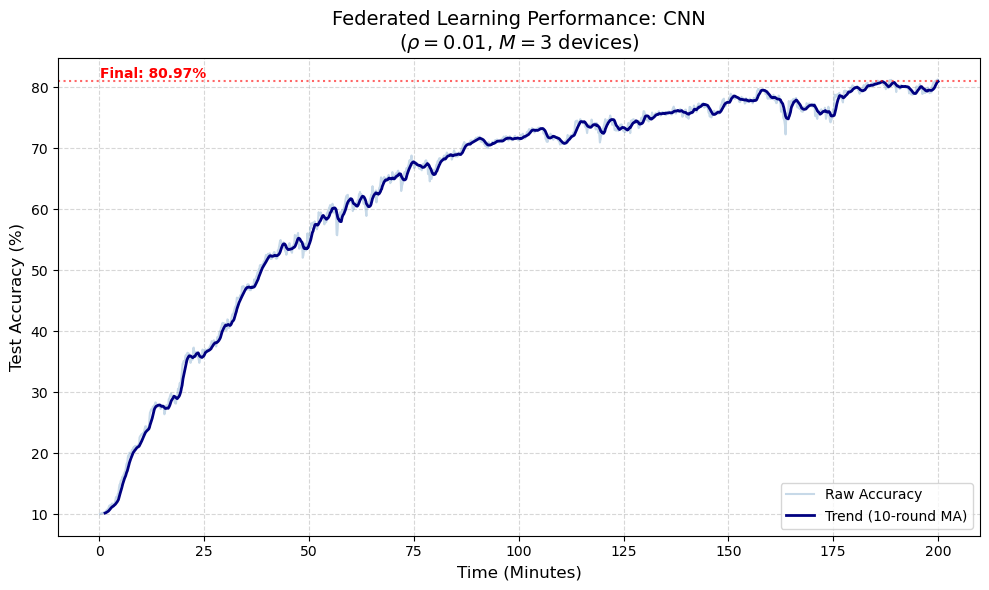

In [ ]:
his = run_multi_device_fl(task='CNN', training_time=12000, rho= 2e-1, M=3, r_km=r_km)

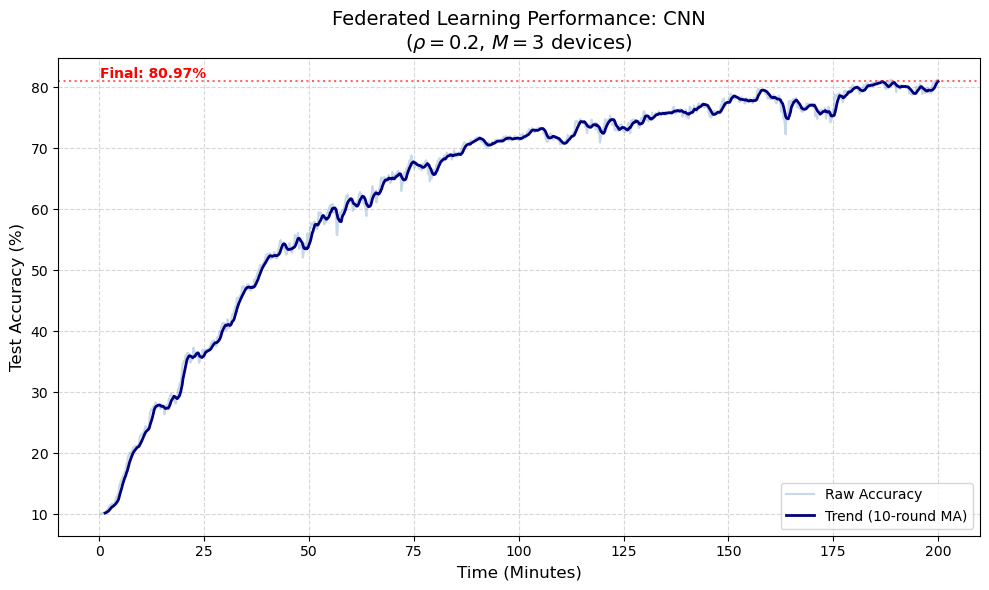

In [16]:
# Execute the plot
plot_fl_history(his, task_name="CNN", rho=2e-1, M=3)

In [30]:
# --- Execution ---
log_file = 'output.log'

# Extracting for rho=0 (Channel-aware) and rho=1 (Importance-aware)
his1 = extract_fl_logs(log_file, "Channel-aware", max_time=12000)
his2 = extract_fl_logs(log_file, "Importance-aware", max_time=12000)

print(f"Extraction Complete!")
print(f"his1 (Channel-aware) rounds: {len(his1['acc'])}")
print(f"his2 (Importance-aware) rounds: {len(his2['acc'])}")

Extraction Complete!
his1 (Channel-aware) rounds: 0
his2 (Importance-aware) rounds: 0


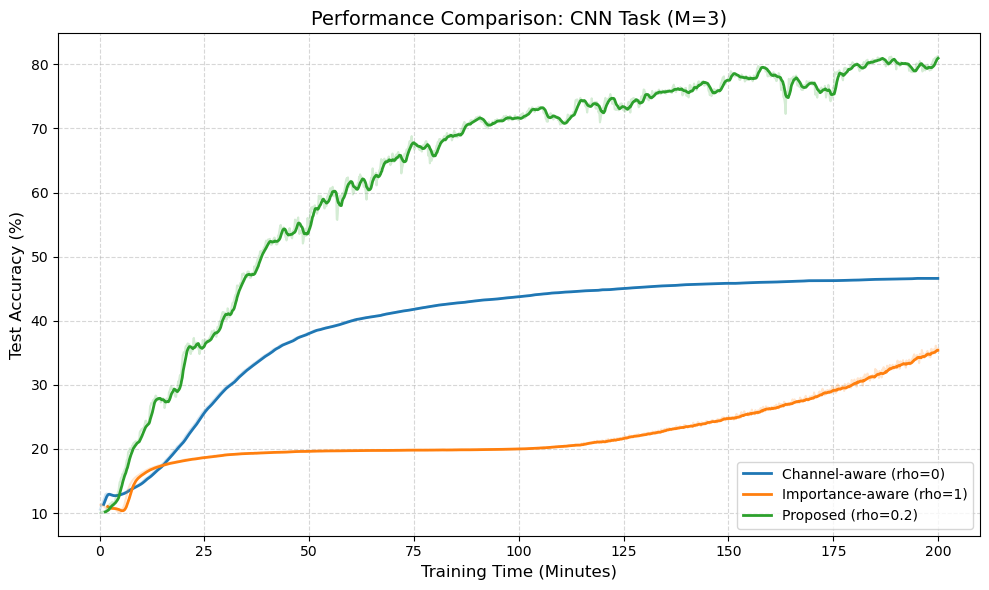

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Create a single figure and axis
plt.figure(figsize=(10, 6))

# 2. Define a helper to handle potential empty data and smoothing
def add_to_plot(history, label, color):
    if not history or 'acc' not in history or len(history['acc']) == 0:
        print(f"Warning: {label} has no data!")
        return
    
    # Convert time to minutes for a cleaner x-axis
    times = np.array(history['time']) / 60 
    accs = np.array(history['acc'])
    
    # Plot the raw data (faded/thin) to show the 'spikes'
    plt.plot(times, accs, alpha=0.2, color=color)
    
    # Plot a Moving Average (thick) to see the actual learning trend
    window = 10
    if len(accs) > window:
        smoothed = np.convolve(accs, np.ones(window)/window, mode='valid')
        plt.plot(times[window-1:], smoothed, label=label, color=color, linewidth=2)
    else:
        plt.plot(times, accs, label=label, color=color, linewidth=2)

# 3. Add all three lines to the SAME plot
add_to_plot(his1, "Channel-aware (rho=0)", "tab:blue")
add_to_plot(his2, "Importance-aware (rho=1)", "tab:orange")
add_to_plot(his,  "Proposed (rho=0.2)", "tab:green")

# 4. Final Styling
plt.title("Performance Comparison: CNN Task (M=3)", fontsize=14)
plt.xlabel("Training Time (Minutes)", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# 5. Show only ONCE at the very end
plt.tight_layout()
plt.show()